In [1]:
from google.colab import files
files.upload()

Saving Career_Switch_Prediction_Dataset.csv to Career_Switch_Prediction_Dataset.csv


{'Career_Switch_Prediction_Dataset.csv': b'enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career\n8949,city_103,0.92,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,,,1,36,1\n29725,city_40,0.7759999999999999,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0\n11561,city_21,0.624,,No relevent experience,Full time course,Graduate,STEM,5,,,0,83,0\n33241,city_115,0.789,,No relevent experience,,Graduate,Business Degree,<1,,Pvt Ltd,0,52,1\n666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0\n21651,city_176,0.764,,Has relevent experience,Part time course,Graduate,STEM,11,,,1,24,1\n28806,city_160,0.92,Male,Has relevent experience,no_enrollment,High School,,5,50-99,Funded Startup,1,24,0\n402,city_46,0.762,Male,Has relevent experience,no_enrollment,Grad

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, roc_auc_score, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
df = pd.read_csv("Career_Switch_Prediction_Dataset.csv")

print('Shape of the dataset is {}. This dataset contains {} rows and {} columns.'.format(
    df.shape, df.shape[0], df.shape[1]))

df.head(10)

Shape of the dataset is (5000, 14). This dataset contains 5000 rows and 14 columns.


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,0,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,0,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0
5,21651,city_176,0.764,NaN,Has relevent experience,Part time course,Graduate,STEM,11,NaN,NaN,1,24,1
6,28806,city_160,0.920,Male,Has relevent experience,no_enrollment,High School,NaN,5,50-99,Funded Startup,1,24,0
7,402,city_46,0.762,Male,Has relevent experience,no_enrollment,Graduate,STEM,13,<10,Pvt Ltd,>4,18,1
8,27107,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,7,50-99,Pvt Ltd,1,46,1
9,699,city_103,0.920,NaN,Has relevent experience,no_enrollment,Graduate,STEM,17,10000+,Pvt Ltd,>4,123,0


In [4]:
#Feature Names and Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             5000 non-null   int64  
 1   city                    5000 non-null   object 
 2   city_development_index  5000 non-null   float64
 3   gender                  3887 non-null   object 
 4   relevent_experience     5000 non-null   object 
 5   enrolled_university     4893 non-null   object 
 6   education_level         4882 non-null   object 
 7   major_discipline        4276 non-null   object 
 8   experience              4989 non-null   object 
 9   company_size            3429 non-null   object 
 10  company_type            3379 non-null   object 
 11  last_new_job            4896 non-null   object 
 12  training_hours          5000 non-null   int64  
 13  will_change_career      5000 non-null   int64  
dtypes: float64(1), int64(3), object(10)
memo

In [5]:
#Numerical Features
numerical_data = df.select_dtypes(include='number')
numerical_features = numerical_data.columns.tolist()

print(f'There are {len(numerical_features)} numerical features:\n')
print(numerical_features)
print()

numerical_data.describe().T

There are 4 numerical features:

['enrollee_id', 'city_development_index', 'training_hours', 'will_change_career']



,count,mean,std,min,25%,50%,75%,max
enrollee_id,5000.0,17022.88300,9656.969716,7.000,8736.500,17068.000,25389.25,33380.000
city_development_index,5000.0,0.82941,0.122429,0.448,0.743,0.903,0.92,0.949
training_hours,5000.0,65.02720,59.946693,1.000,23.000,47.000,88.00,336.000
will_change_career,5000.0,0.25240,0.434433,0.000,0.000,0.000,1.00,1.000


In [6]:
#Categorical Features
categorical_data = df.select_dtypes(include='object')
categorical_features = categorical_data.columns.tolist()

print(f'There are {len(categorical_features)} categorical features:\n')
print(categorical_features)
print()

categorical_data.describe().T

There are 10 categorical features:

['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']



,count,unique,top,freq
city,5000,113,city_103,1163
gender,3887,3,Male,3507
relevent_experience,5000,2,Has relevent experience,3598
enrolled_university,4893,3,no_enrollment,3571
education_level,4882,5,Graduate,3037
major_discipline,4276,6,STEM,3786
experience,4989,22,>20,859
company_size,3429,8,50-99,813
company_type,3379,6,Pvt Ltd,2550
last_new_job,4896,6,1,2094


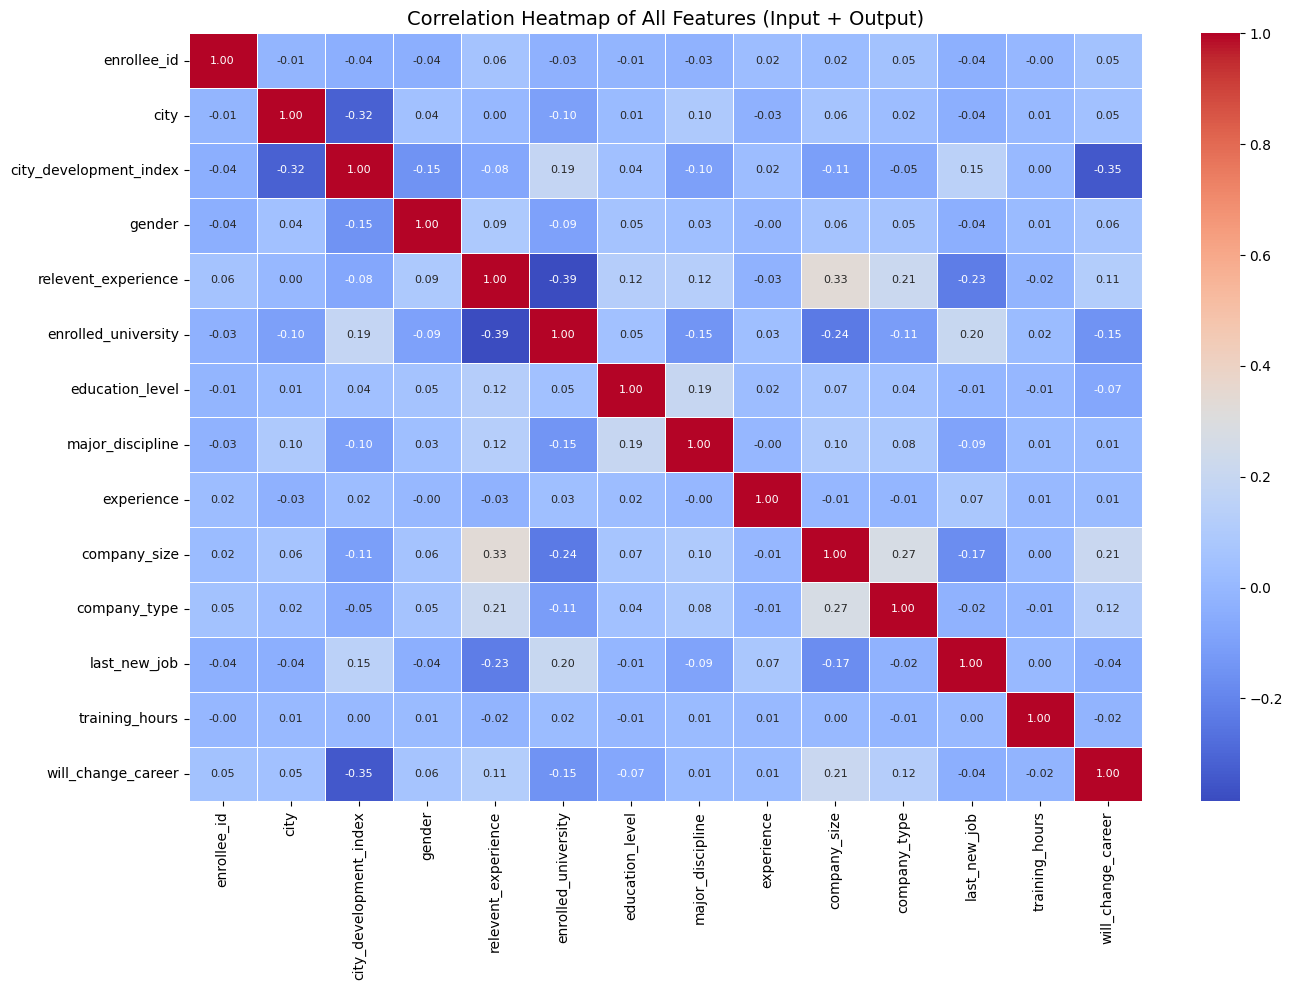

In [7]:
#Correlation Heatmap
df_corr = df.copy()
le_temp = LabelEncoder()

for col in df_corr.select_dtypes(include='object').columns:
    df_corr[col] = df_corr[col].fillna('Unknown')
    df_corr[col] = le_temp.fit_transform(df_corr[col])

df_corr = df_corr.fillna(df_corr.median())

plt.figure(figsize=(14, 10))
sns.heatmap(
    df_corr.corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Heatmap of All Features (Input + Output)', fontsize=14)
plt.tight_layout()
plt.show()

Class Distribution:
will_change_career
0    3738
1    1262
Name: count, dtype: int64

Percentage:
will_change_career
0    74.76
1    25.24
Name: count, dtype: float64


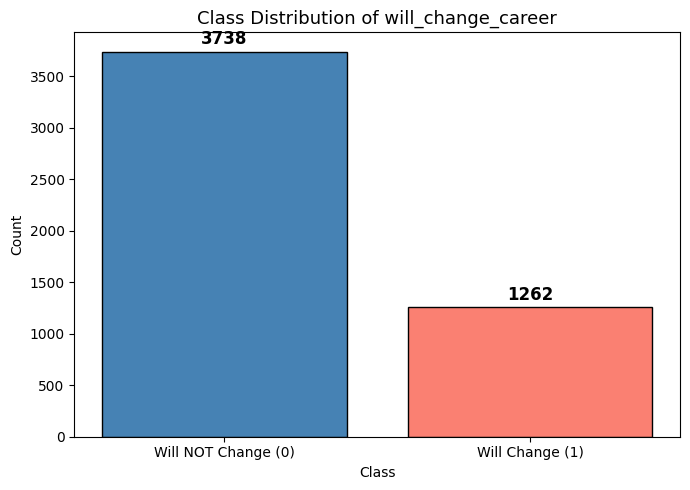

In [8]:
#Imbalanced Dataset
class_counts = df['will_change_career'].value_counts()

print("Class Distribution:")
print(class_counts)
print(f"\nPercentage:\n{round(class_counts / len(df) * 100, 2)}")

plt.figure(figsize=(7, 5))
bars = plt.bar(
    ['Will NOT Change (0)', 'Will Change (1)'],
    class_counts.values,
    color=['steelblue', 'salmon'],
    edgecolor='black'
)
for bar, count in zip(bars, class_counts.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        str(count), ha='center', va='bottom', fontsize=12, fontweight='bold'
    )
plt.title('Class Distribution of will_change_career', fontsize=13)
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

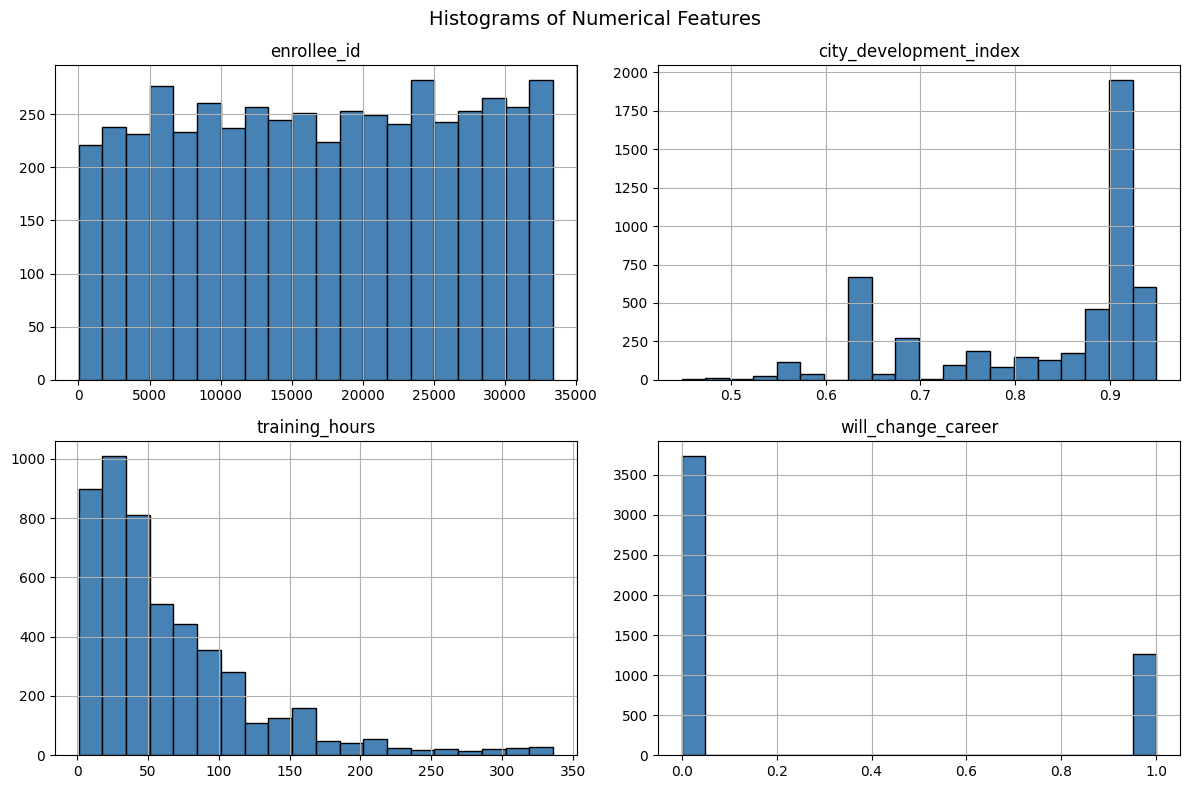

In [9]:
#EDA 1 — Histograms of Numerical Features
numerical_data.hist(figsize=(12, 8), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Histograms of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

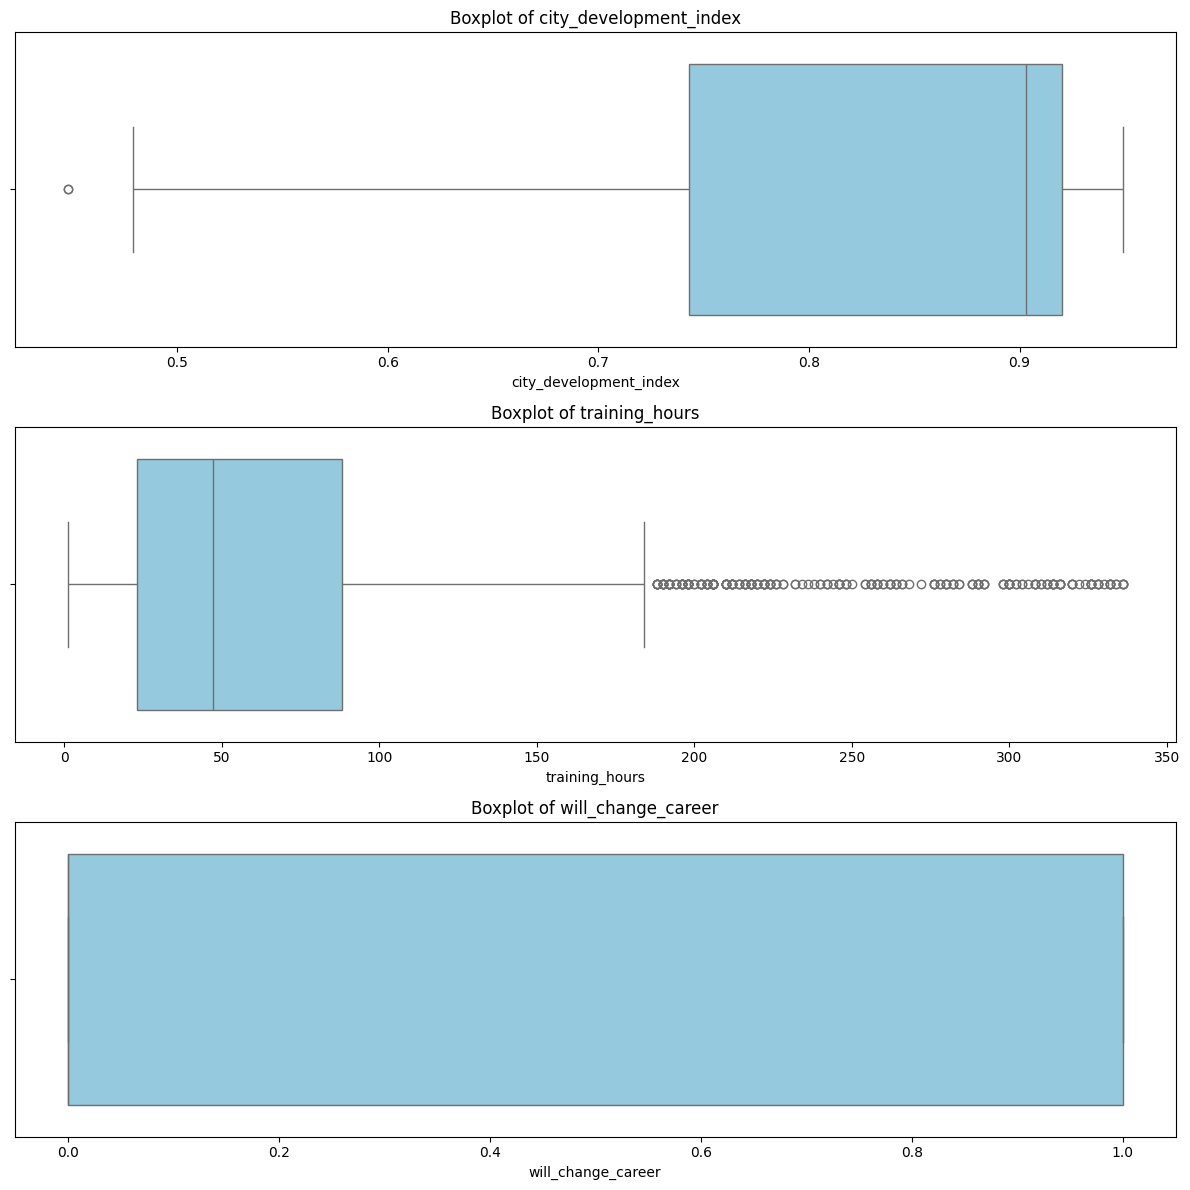

In [10]:
#EDA 2 — Boxplots for Outlier Detection
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'enrollee_id']

plt.figure(figsize=(12, 4 * len(numeric_cols)))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(len(numeric_cols), 1, i)
    sns.boxplot(x=df[col], color='skyblue')
    plt.title(f'Boxplot of {col}', fontsize=12)
    plt.tight_layout()
plt.show()

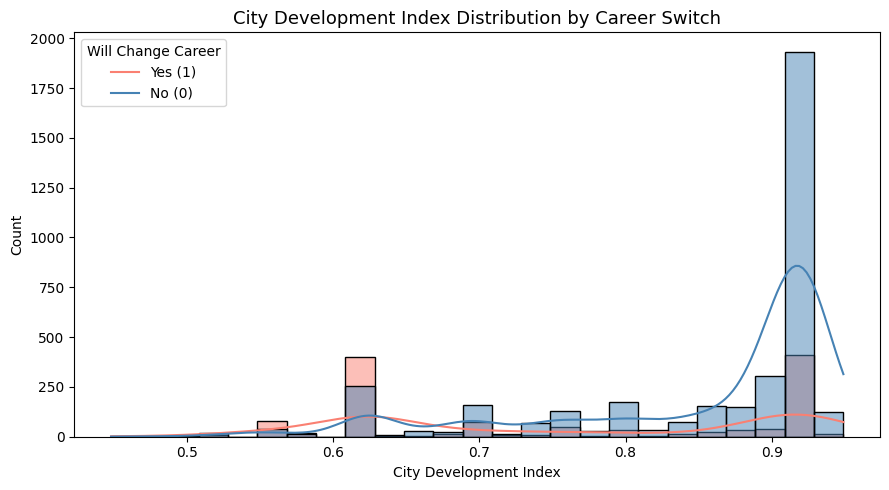

In [11]:
#EDA 3 — City Development Index vs Career Switch
plt.figure(figsize=(9, 5))
sns.histplot(
    data=df,
    x='city_development_index',
    hue='will_change_career',
    kde=True,
    palette={0: 'steelblue', 1: 'salmon'}
)
plt.title('City Development Index Distribution by Career Switch', fontsize=13)
plt.xlabel('City Development Index')
plt.ylabel('Count')
plt.legend(title='Will Change Career', labels=['Yes (1)', 'No (0)'])
plt.tight_layout()
plt.show()

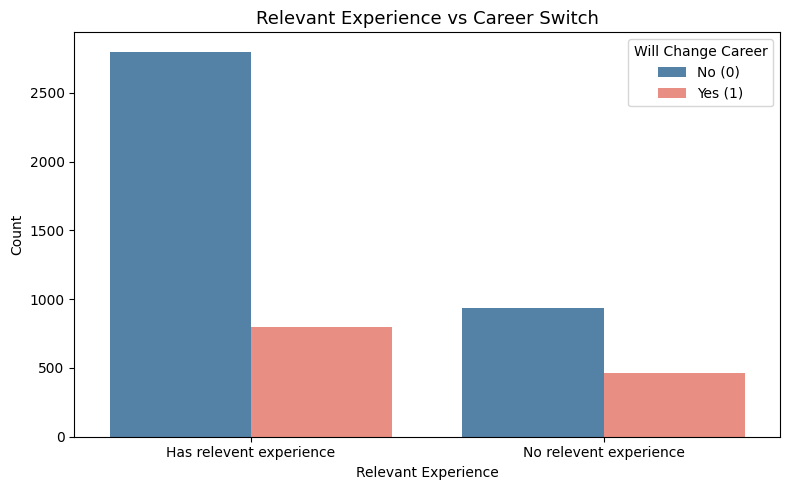

In [12]:
#EDA 4 — Relevant Experience vs Career Switch
plt.figure(figsize=(8, 5))
sns.countplot(
    x='relevent_experience',
    hue='will_change_career',
    data=df,
    palette={0: 'steelblue', 1: 'salmon'}
)
plt.title('Relevant Experience vs Career Switch', fontsize=13)
plt.xlabel('Relevant Experience')
plt.ylabel('Count')
plt.legend(title='Will Change Career', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

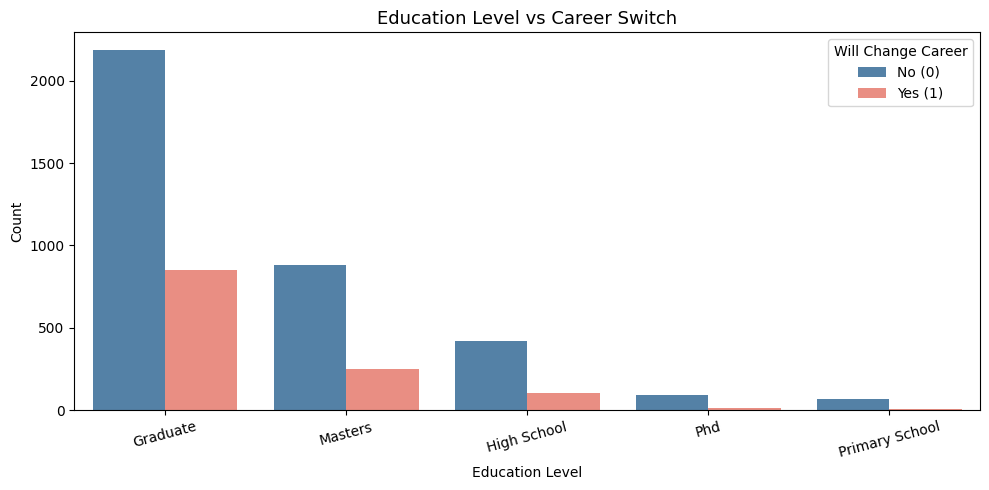

In [13]:
#EDA 5 — Education Level vs Career Switch
plt.figure(figsize=(10, 5))
edu_order = df['education_level'].value_counts().index.tolist()
sns.countplot(
    x='education_level',
    hue='will_change_career',
    data=df,
    order=edu_order,
    palette={0: 'steelblue', 1: 'salmon'}
)
plt.title('Education Level vs Career Switch', fontsize=13)
plt.xlabel('Education Level')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Will Change Career', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

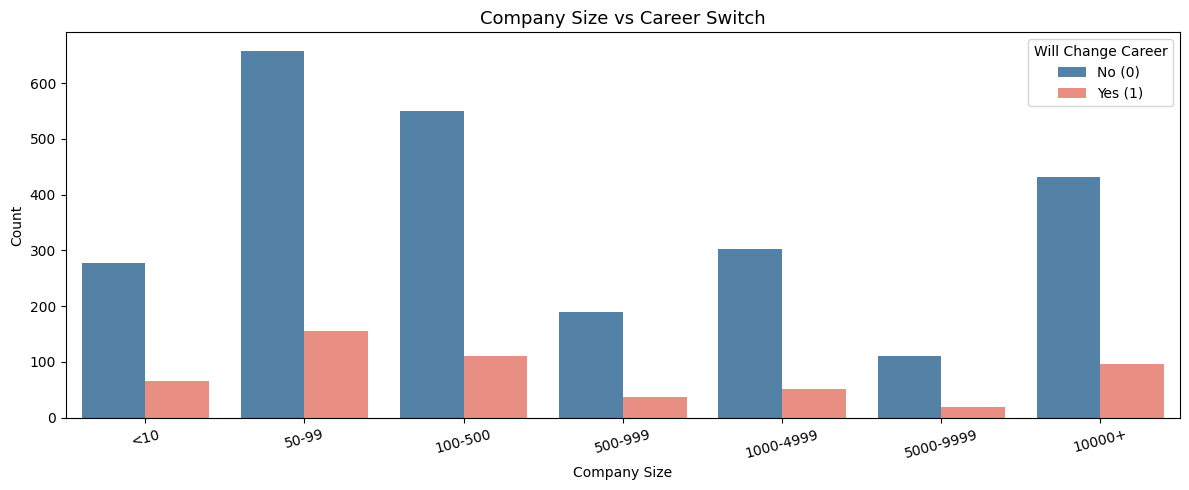

In [14]:
#EDA 6 — Company Size vs Career Switch
plt.figure(figsize=(12, 5))
size_order = ['<10', '10/49', '50-99', '100-500', '500-999', '1000-4999', '5000-9999', '10000+']
size_order = [s for s in size_order if s in df['company_size'].dropna().unique()]

sns.countplot(
    x='company_size',
    hue='will_change_career',
    data=df,
    order=size_order,
    palette={0: 'steelblue', 1: 'salmon'}
)
plt.title('Company Size vs Career Switch', fontsize=13)
plt.xlabel('Company Size')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.legend(title='Will Change Career', labels=['No (0)', 'Yes (1)'])
plt.tight_layout()
plt.show()

In [15]:
#EDA 7 — Skewness of Numerical Features
print("Skewness of Numerical Features:")
print(numerical_data.skew())

Skewness of Numerical Features:
enrollee_id              -0.022808
city_development_index   -1.013328
training_hours            1.853677
will_change_career        1.140333
dtype: float64


In [16]:
#Fault 1: Check Missing Values
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Missing values per column:
enrollee_id                  0
city                         0
city_development_index       0
gender                    1113
relevent_experience          0
enrolled_university        107
education_level            118
major_discipline           724
experience                  11
company_size              1571
company_type              1621
last_new_job               104
training_hours               0
will_change_career           0
dtype: int64

Total missing values: 5369


In [17]:
#Solution 1: Drop enrollee_id + Mode Imputation
df_clean = df.copy()


df_clean.drop(columns=['enrollee_id'], inplace=True)
print("Dropped enrollee_id column.")


cat_cols_with_nulls = [
    'gender', 'enrolled_university', 'education_level',
    'major_discipline', 'experience', 'company_size',
    'company_type', 'last_new_job'
]

for col in cat_cols_with_nulls:
    mode_val = df_clean[col].mode()[0] # most freq value
    df_clean[col].fillna(mode_val, inplace=True)
    print(f'  Filled "{col}" missing values with mode: "{mode_val}"')

print("\nMissing values after imputation:")
print(df_clean.isnull().sum())

Dropped enrollee_id column.
  Filled "gender" missing values with mode: "Male"
  Filled "enrolled_university" missing values with mode: "no_enrollment"
  Filled "education_level" missing values with mode: "Graduate"
  Filled "major_discipline" missing values with mode: "STEM"
  Filled "experience" missing values with mode: ">20"
  Filled "company_size" missing values with mode: "50-99"
  Filled "company_type" missing values with mode: "Pvt Ltd"
  Filled "last_new_job" missing values with mode: "1"

Missing values after imputation:
city                      0
city_development_index    0
gender                    0
relevent_experience       0
enrolled_university       0
education_level           0
major_discipline          0
experience                0
company_size              0
company_type              0
last_new_job              0
training_hours            0
will_change_career        0
dtype: int64


In [18]:
#Fault 2: Categorical Variables — Check
print("Categorical columns that need encoding:")
print(df_clean.select_dtypes(include='object').columns.tolist())

Categorical columns that need encoding:
['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']


In [19]:
#Solution 2: Label Encoding
le = LabelEncoder()

categorical_cols_to_encode = [
    'city', 'gender', 'relevent_experience', 'enrolled_university',
    'education_level', 'major_discipline', 'experience',
    'company_size', 'company_type', 'last_new_job'
]

for col in categorical_cols_to_encode:
    df_clean[col] = le.fit_transform(df_clean[col])
    print(f"Encoded: {col}")

print("\nDataset after encoding (first 5 rows):")
df_clean.head()

Encoded: city
Encoded: gender
Encoded: relevent_experience
Encoded: enrolled_university
Encoded: education_level
Encoded: major_discipline
Encoded: experience
Encoded: company_size
Encoded: company_type
Encoded: last_new_job

Dataset after encoding (first 5 rows):


,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,will_change_career
0,5,0.920,1,0,2,0,5,21,3,5,1,36,1
1,68,0.776,1,1,2,0,5,6,3,5,5,47,0
2,56,0.624,1,1,0,0,5,15,3,5,0,83,0
3,13,0.789,1,1,2,0,1,20,3,5,0,52,1
4,46,0.767,1,0,2,2,5,21,3,1,4,8,0


In [20]:
#Fault 3 + Solution 3: Feature Scaling
X = df_clean.drop(columns=['will_change_career'])
y = df_clean['will_change_career']

print("Features shape:", X.shape)
print("Target shape  :", y.shape)
print("Feature columns:", X.columns.tolist())

Features shape: (5000, 12)
Target shape  : (5000,)
Feature columns: ['city', 'city_development_index', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job', 'training_hours']


In [21]:
#Stratified Train-Test Split (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set: X = {}, y = {}".format(X_train.shape, y_train.shape))
print("Testing  set: X = {}, y = {}".format(X_test.shape, y_test.shape))
print("\nClass distribution in train set:")
print(y_train.value_counts())
print("\nClass distribution in test set:")
print(y_test.value_counts())

Training set: X = (4000, 12), y = (4000,)
Testing  set: X = (1000, 12), y = (1000,)

Class distribution in train set:
will_change_career
0    2990
1    1010
Name: count, dtype: int64

Class distribution in test set:
will_change_career
0    748
1    252
Name: count, dtype: int64


In [22]:
#Apply StandardScaler (fit on train, transform both)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete.")
print("Train mean (first 3 features):", X_train_scaled[:, :3].mean(axis=0).round(4))
print("Train std  (first 3 features):", X_train_scaled[:, :3].std(axis=0).round(4))

Scaling complete.
Train mean (first 3 features): [-0. -0. -0.]
Train std  (first 3 features): [1. 1. 1.]


In [23]:
#Model 1: KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("=== KNN Classifier ===")
print("Training accuracy of the model is {:.4f}".format(knn.score(X_train_scaled, y_train)))
print("Testing  accuracy of the model is {:.4f}".format(accuracy_score(y_test, y_pred_knn)))
print()
print(classification_report(y_test, y_pred_knn, target_names=['No Change (0)', 'Will Change (1)']))

=== KNN Classifier ===
Training accuracy of the model is 0.8203
Testing  accuracy of the model is 0.7350

                 precision    recall  f1-score   support

  No Change (0)       0.80      0.87      0.83       748
Will Change (1)       0.47      0.35      0.40       252

       accuracy                           0.73      1000
      macro avg       0.63      0.61      0.61      1000
   weighted avg       0.71      0.73      0.72      1000



In [24]:
#Model 2: Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=10)
dt.fit(X_train_scaled, y_train)

y_pred_dt = dt.predict(X_test_scaled)

print("=== Decision Tree Classifier ===")
print("Training accuracy of the model is {:.4f}".format(dt.score(X_train_scaled, y_train)))
print("Testing  accuracy of the model is {:.4f}".format(accuracy_score(y_test, y_pred_dt)))
print()
print(classification_report(y_test, y_pred_dt, target_names=['No Change (0)', 'Will Change (1)']))

=== Decision Tree Classifier ===
Training accuracy of the model is 0.8708
Testing  accuracy of the model is 0.7470

                 precision    recall  f1-score   support

  No Change (0)       0.82      0.85      0.83       748
Will Change (1)       0.50      0.44      0.47       252

       accuracy                           0.75      1000
      macro avg       0.66      0.64      0.65      1000
   weighted avg       0.74      0.75      0.74      1000



In [25]:
#Model 3: Neural Network (MLP)
nn = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1
)
nn.fit(X_train_scaled, y_train)

y_pred_nn = nn.predict(X_test_scaled)

print("=== Neural Network (MLP) ===")
print("Training accuracy of the model is {:.4f}".format(nn.score(X_train_scaled, y_train)))
print("Testing  accuracy of the model is {:.4f}".format(accuracy_score(y_test, y_pred_nn)))
print()
print(classification_report(y_test, y_pred_nn, target_names=['No Change (0)', 'Will Change (1)']))

=== Neural Network (MLP) ===
Training accuracy of the model is 0.7475
Testing  accuracy of the model is 0.7480

                 precision    recall  f1-score   support

  No Change (0)       0.75      1.00      0.86       748
Will Change (1)       0.00      0.00      0.00       252

       accuracy                           0.75      1000
      macro avg       0.37      0.50      0.43      1000
   weighted avg       0.56      0.75      0.64      1000



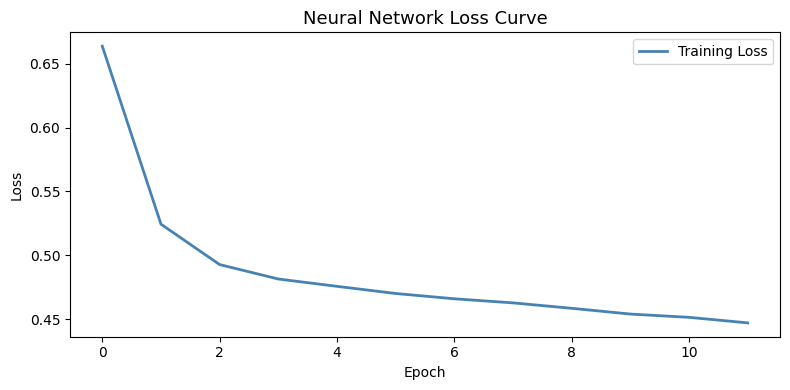

In [26]:
#Neural Network — Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(nn.loss_curve_, label='Training Loss', color='steelblue', linewidth=2)
plt.title('Neural Network Loss Curve', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
#Unsupervised: K-Means Clustering-(group-2)
km = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = km.fit_predict(X_train_scaled)

print("KMeans cluster sizes:")
unique, counts = np.unique(clusters, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Cluster {u}: {c} samples")

KMeans cluster sizes:
  Cluster 0: 2693 samples
  Cluster 1: 1307 samples


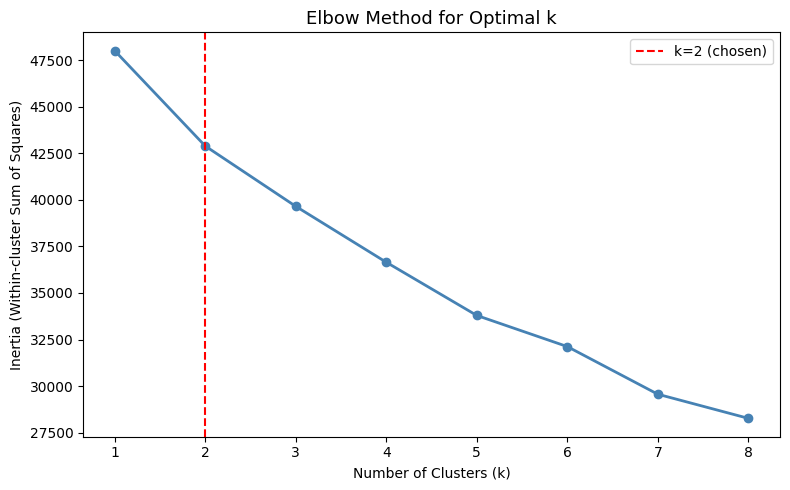

In [28]:
#KMeans — Elbow Method
inertia_values = []
k_range = range(1, 9)

for k in k_range:
    km_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_temp.fit(X_train_scaled)
    inertia_values.append(km_temp.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o', color='steelblue', linewidth=2)
plt.axvline(x=2, color='red', linestyle='--', label='k=2 (chosen)')
plt.title('Elbow Method for Optimal k', fontsize=13)
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.legend()
plt.tight_layout()
plt.show()

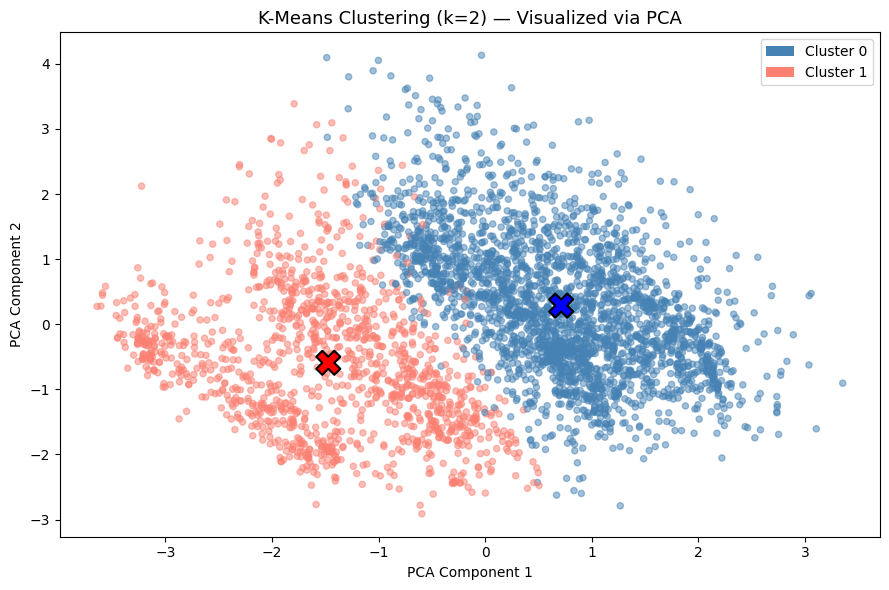

Explained variance by 2 PCA components: 25.53%


In [29]:
#KMeans — Cluster Visualization using PCA
pca = PCA(n_components=2, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)

color_map = {0: 'steelblue', 1: 'salmon'}
colors = [color_map[c] for c in clusters]

plt.figure(figsize=(9, 6))
plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1],
            c=colors, alpha=0.5, s=20)

centroids_pca = pca.transform(km.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
            c=['blue', 'red'], s=300, marker='X',
            edgecolors='black', linewidths=1.5,
            label='Centroids', zorder=5)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', label='Cluster 0'),
    Patch(facecolor='salmon',    label='Cluster 1'),
]
plt.legend(handles=legend_elements)
plt.title('K-Means Clustering (k=2) — Visualized via PCA', fontsize=13)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.tight_layout()
plt.show()

print(f"Explained variance by 2 PCA components: {pca.explained_variance_ratio_.sum():.2%}")

In [37]:
#Model Comparison Analysis
model_names = ['KNN', 'Decision Tree','Neural Network']
models_list = [knn, dt, nn]
y_preds     = [y_pred_knn, y_pred_dt,y_pred_nn]

results = {}
for name, model, y_pred in zip(model_names, models_list, y_preds):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)

    y_prob    = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    results[name] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'auc': auc_score}

results_df = pd.DataFrame(results).T.round(4)
print("Model Comparison:")
print(results_df)

Model Comparison:
                accuracy  precision  recall     auc
KNN                0.735     0.4652  0.3452  0.6729
Decision Tree      0.747     0.4977  0.4365  0.6562
Neural Network     0.748     0.0000  0.0000  0.6300


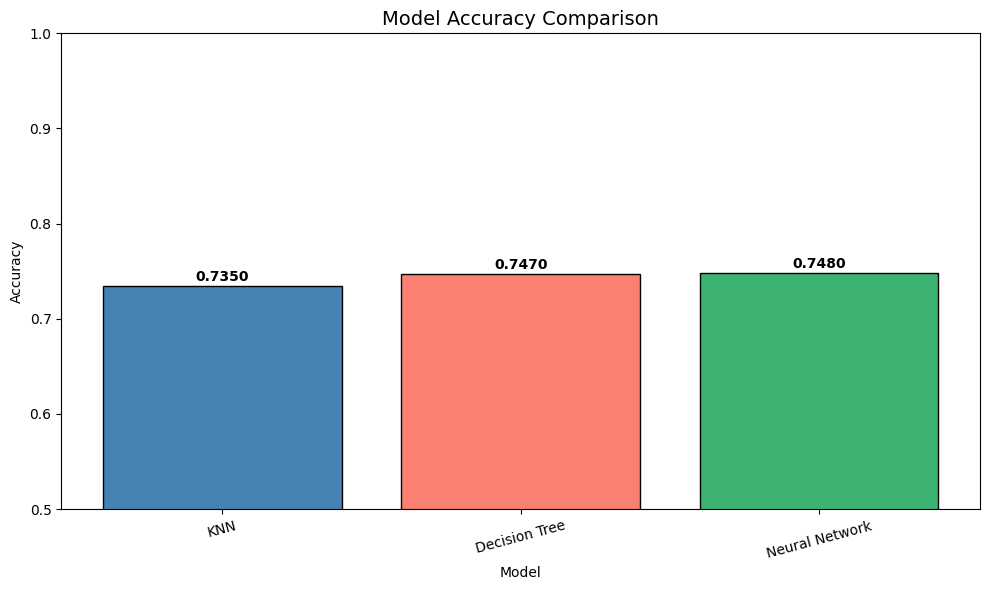

In [38]:
#Bar Chart — Accuracy Comparison
colors = ['steelblue', 'salmon', 'mediumseagreen']

plt.figure(figsize=(10, 6))
bars = plt.bar(
    model_names,
    results_df['accuracy'].values,
    color=colors,
    edgecolor='black'
)
for bar, val in zip(bars, results_df['accuracy'].values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.title('Model Accuracy Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

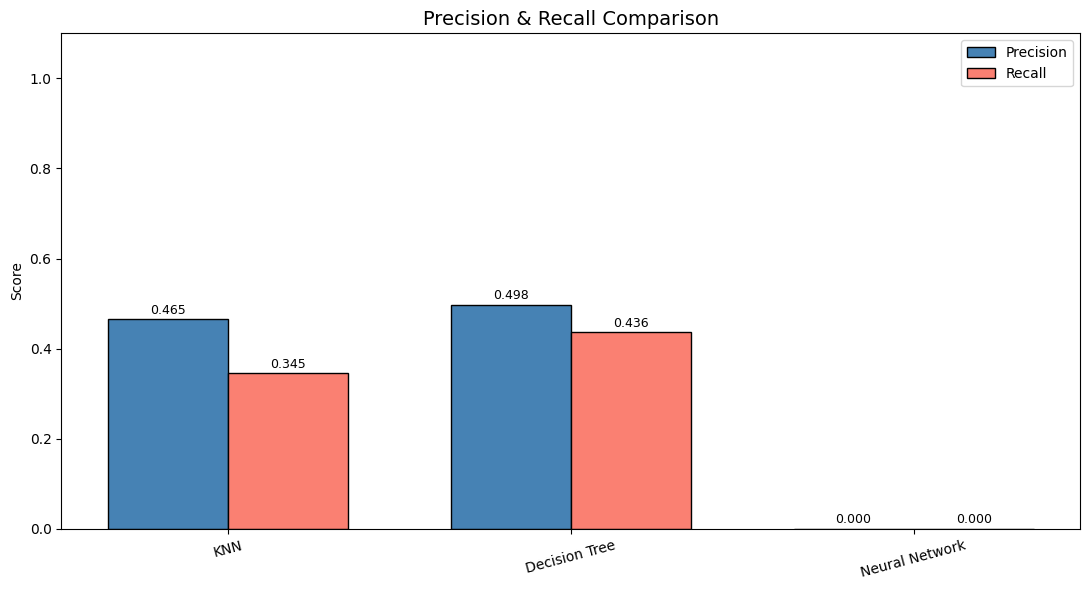

In [32]:
#Bar Chart — Precision & Recall Comparison
x = np.arange(len(model_names))
width = 0.35

plt.figure(figsize=(11, 6))
bars1 = plt.bar(x - width/2, results_df['precision'].values, width,
                label='Precision', color='steelblue', edgecolor='black')
bars2 = plt.bar(x + width/2, results_df['recall'].values, width,
                label='Recall',    color='salmon',    edgecolor='black')

for bar, val in zip(bars1, results_df['precision'].values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, results_df['recall'].values):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.title('Precision & Recall Comparison', fontsize=14)
plt.xticks(x, model_names, rotation=15)
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.legend()
plt.tight_layout()
plt.show()

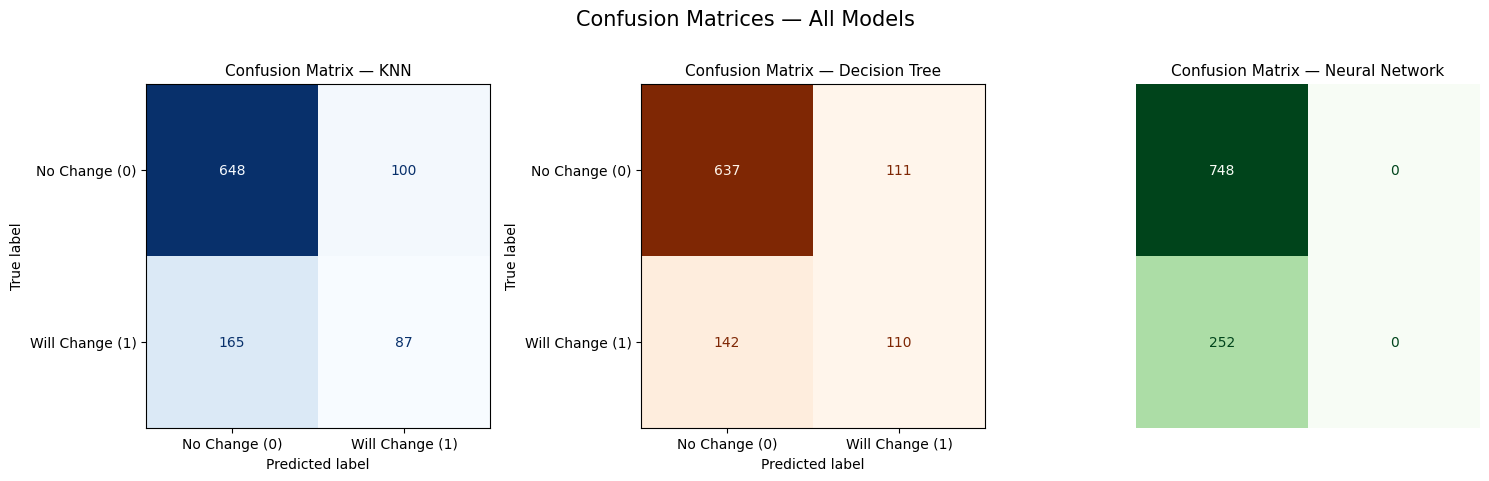

In [33]:
#Confusion Matrix — All 3 Models
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

cmaps = ['Blues', 'Oranges', 'Greens']

for i, (name, y_pred) in enumerate(zip(model_names, y_preds)):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Change (0)', 'Will Change (1)'])
    disp.plot(ax=axes[i], cmap=cmaps[i], colorbar=False)
    axes[i].set_title(f'Confusion Matrix — {name}', fontsize=11)

axes[-1].axis('off')
plt.suptitle('Confusion Matrices — All Models', fontsize=15)
plt.tight_layout()
plt.show()

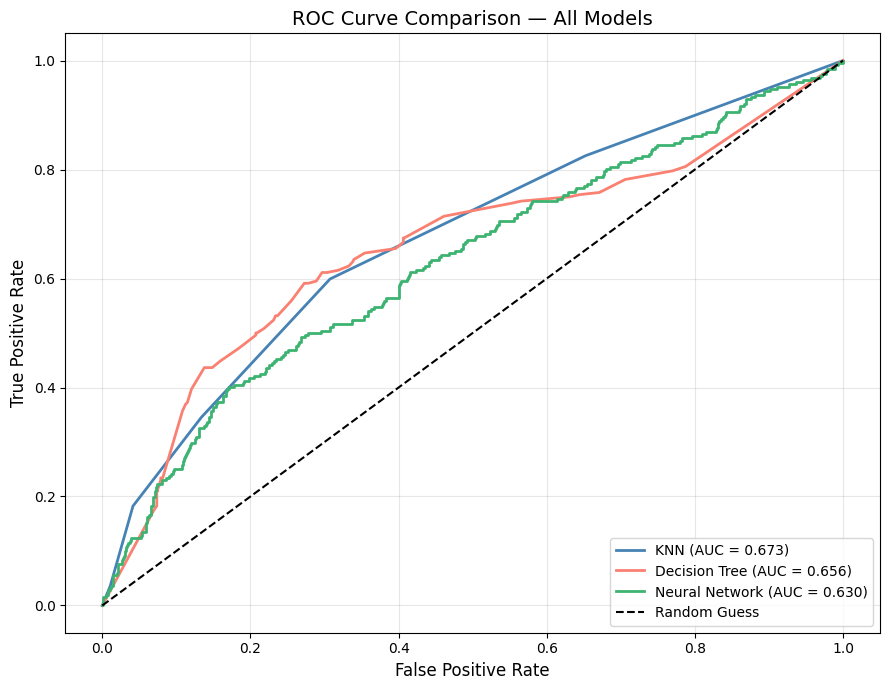

In [34]:
#ROC Curves — All 3 Models
line_colors = ['steelblue', 'salmon', 'mediumseagreen']

plt.figure(figsize=(9, 7))
for name, model, color in zip(model_names, models_list, line_colors):
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.3f})',
                 color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess', linewidth=1.5)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve Comparison — All Models', fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

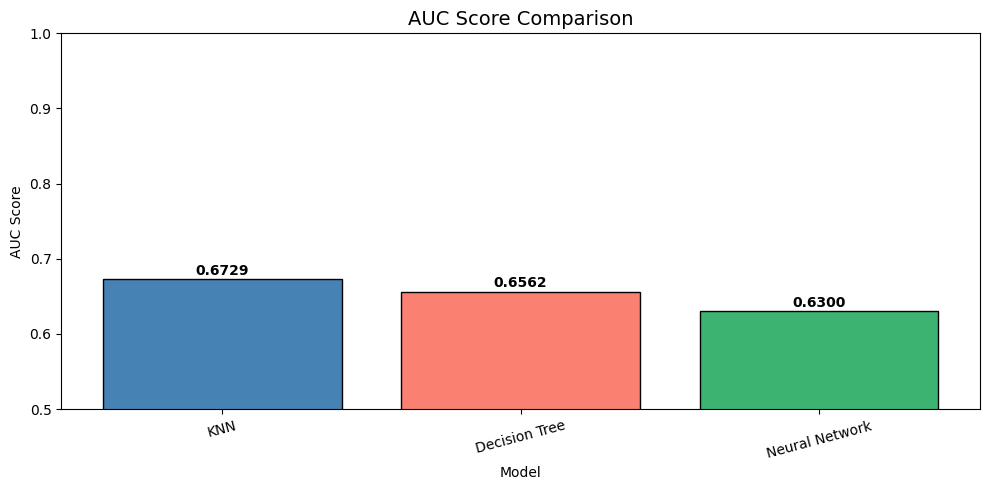

In [35]:
#Bar Chart — AUC Score Comparison
auc_vals = results_df['auc'].values.astype(float)

plt.figure(figsize=(10, 5))
bars = plt.bar(
    model_names, auc_vals,
    color=['steelblue', 'salmon', 'mediumseagreen'],
    edgecolor='black'
)
for bar, val in zip(bars, auc_vals):
    plt.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.ylim(0.5, 1.0)
plt.title('AUC Score Comparison', fontsize=14)
plt.xlabel('Model')
plt.ylabel('AUC Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [36]:
#Final Summary Table
print('=' * 65)
print(f'{"Model":<22} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"AUC":>10}')
print('=' * 65)
for name in model_names:
    r = results[name]
    auc_str = f"{r['auc']:.4f}" if r['auc'] is not None else 'N/A'
    print(f"{name:<22} {r['accuracy']:>10.4f} {r['precision']:>10.4f} {r['recall']:>10.4f} {auc_str:>10}")
print('=' * 65)

Model                    Accuracy  Precision     Recall        AUC
KNN                        0.7350     0.4652     0.3452     0.6729
Decision Tree              0.7470     0.4977     0.4365     0.6562
Neural Network             0.7480     0.0000     0.0000     0.6300
